In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income($)')

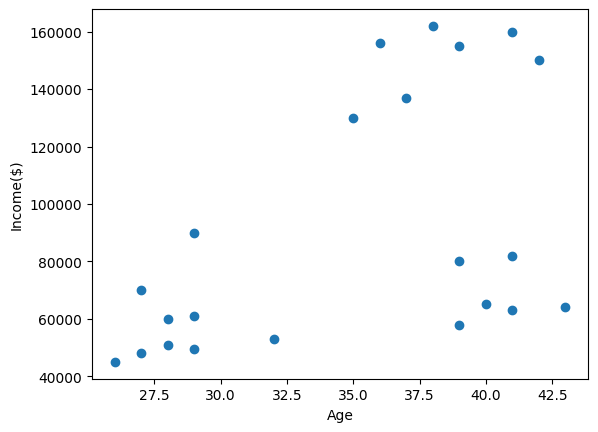

In [3]:
plt.scatter(df.Age,df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')

In [4]:
km = KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [5]:
df.iloc[:,1:3]

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [6]:
y_predicted=km.fit_predict(df.iloc[:,1:3])
y_predicted

array([1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2])

In [7]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,0


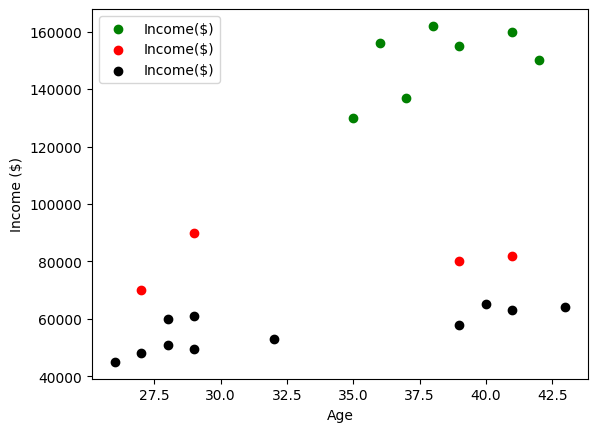

In [8]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
#plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.xlabel('Age')
plt.ylabel('Income ($)')
plt.legend(['Income($)','Income($)','Income($)'])

In [9]:
#Scaling

In [10]:
scaler = MinMaxScaler()

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [11]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,0


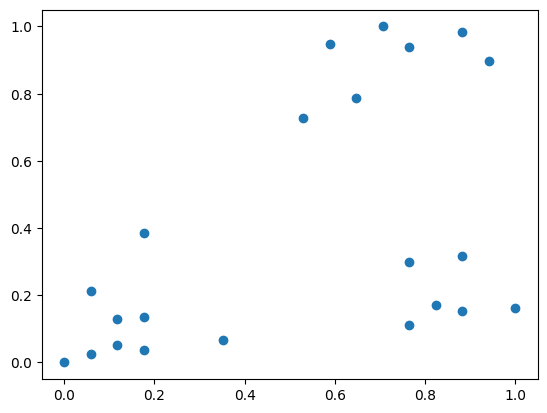

In [12]:
plt.scatter(df.Age,df['Income($)'])

In [13]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income($)']])
y_predicted

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

In [14]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,2


In [15]:
km.cluster_centers_

array([[0.85294118, 0.2022792 ],
       [0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ]])

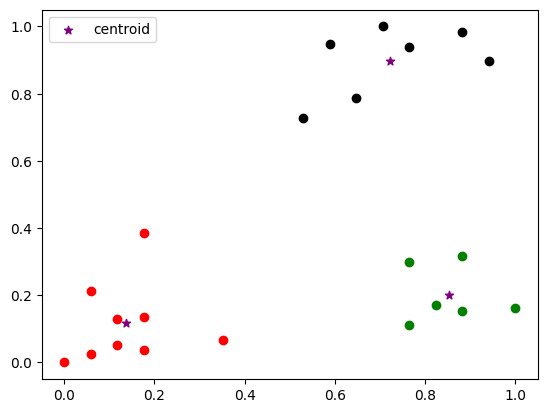

In [16]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
plt.scatter(df1.Age,df1['Income($)'],color='green')
plt.scatter(df2.Age,df2['Income($)'],color='red')
plt.scatter(df3.Age,df3['Income($)'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

Elbow Plot

In [21]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

In [23]:
km.inertia_#in order to get SSE

0.1107356952741864

In [18]:
sse

[5.434011511988178,
 2.0911363886990775,
 0.4750783498553096,
 0.3625079900797329,
 0.27980629310461785,
 0.23047208837899558,
 0.19273286467560863,
 0.15336090579635966,
 0.11623513811466671]

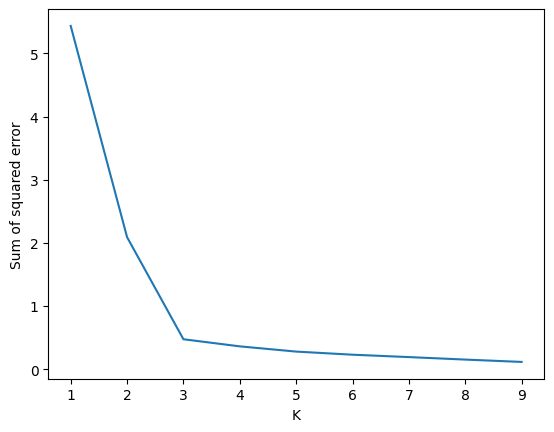

In [19]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

1.When to Use fit_transform() in K-Means

You have a single dataset (no train/test splits).

You want to scale features and cluster in one go.

Scaling + Clustering (Single Dataset)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Sample data
data = {'Income($)': [50000, 80000, 30000], 'Age': [25, 45, 30]}
df = pd.DataFrame(data)

# Step 1: Scale features (fit + transform in one step)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)  # Applies scaling to entire dataset

# Step 2: Apply K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df_scaled)  # Clusters the scaled data

2.When to Use fit() + transform() Separately

You need consistent scaling for new/unseen data (e.g., adding new samples later).

You want to avoid data leakage (important in production).

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Sample data
data = {'Income($)': [50000, 80000, 30000], 'Age': [25, 45, 30]}
df = pd.DataFrame(data)

# Step 1: Fit scaler (learn mean & std)
scaler = StandardScaler()
scaler.fit(df)  # Computes scaling parameters but does not transform yet

# Step 2: Transform the data
df_scaled = scaler.transform(df)  # Applies scaling

# Step 3: Cluster the scaled data
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df_scaled)

# Later, if new data arrives, reuse the same scaler
new_data = pd.DataFrame({'Income($)': [60000], 'Age': [35]})
new_data_scaled = scaler.transform(new_data)  # Uses same mean/std as before

3.When to Use Only transform()

You already fitted a scaler (e.g., in a training phase) and now want to apply it to new data

# Assuming `scaler` and `kmeans` are already fitted (from previous example)

# New data arrives
new_data = pd.DataFrame({'Income($)': [75000, 40000], 'Age': [50, 28]})

# Step 1: Scale new data using the pre-fitted scaler
new_data_scaled = scaler.transform(new_data)  # Uses existing mean/std

# Step 2: Predict clusters for new data
clusters = kmeans.predict(new_data_scaled)
print(clusters)  # Returns cluster labels 

1.When to Use fit_predict()

You want to train the K-means model and get cluster labels immediately (without needing the model object later).

Useful for exploratory data analysis (EDA) or quick clustering tasks

from sklearn.cluster import KMeans
import numpy as np

# Sample data (2D points)
X = np.array([[1, 2], [1, 4], [1, 0], [10, 2], [10, 4], [10, 0]])

# Apply K-means and get cluster labels in one step
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)  # Combines fit() + predict()

print(labels)  # Output: [0 0 0 1 1 1] (cluster assignments)

2.When to Use fit() + predict() Separately

You need to reuse the K-means model (e.g., for new data predictions later).

You want to access cluster centroids (kmeans.cluster_centers_) before assigning labels.

# Fit K-means first (computes centroids)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)  # Only computes centroids, no labels yet

# Access centroids
print("Cluster Centers:\n", kmeans.cluster_centers_)

# Predict labels later
new_data = np.array([[0, 0], [12, 3]])
new_labels = kmeans.predict(new_data)  # Assigns new data to clusters

print(new_labels)  # Output: [0 1] (Cluster assignments for new points)